In [36]:
import pandas as pd

# Data
Se analizara información y caracteristicas del archivo con la información 

In [37]:
df = pd.read_parquet("yellow_tripdata_2022-05.parquet")

In [38]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


In [39]:
df.shape

(3588295, 19)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3588295 entries, 0 to 3588294
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [41]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          129524
trip_distance                 0
RatecodeID               129524
store_and_fwd_flag       129524
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     129524
airport_fee              129524
dtype: int64

In [42]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')

In [43]:
df.describe

<bound method NDFrame.describe of          VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               1  2022-05-01 00:00:36   2022-05-01 00:19:18              1.0   
1               1  2022-05-01 00:27:44   2022-05-01 00:41:33              1.0   
2               1  2022-05-01 00:59:00   2022-05-01 01:14:22              1.0   
3               1  2022-05-01 00:48:18   2022-05-01 01:28:02              1.0   
4               1  2022-05-01 00:28:26   2022-05-01 00:37:49              1.0   
...           ...                  ...                   ...              ...   
3588290         2  2022-05-31 23:40:19   2022-06-01 00:01:20              NaN   
3588291         2  2022-05-31 23:52:12   2022-06-01 00:06:40              NaN   
3588292         2  2022-05-31 23:27:00   2022-05-31 23:48:00              NaN   
3588293         2  2022-05-31 23:34:12   2022-06-01 00:00:13              NaN   
3588294         2  2022-05-31 23:00:53   2022-05-31 23:07:54              N

In [44]:
# Crear duración del viaje en minutos
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df[[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "passenger_count",
    "trip_duration_min"
]].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,passenger_count,trip_duration_min
0,2022-05-01 00:00:36,2022-05-01 00:19:18,4.1,1.0,18.700000
1,2022-05-01 00:27:44,2022-05-01 00:41:33,2.3,1.0,13.816667
2,2022-05-01 00:59:00,2022-05-01 01:14:22,4.2,1.0,15.366667
3,2022-05-01 00:48:18,2022-05-01 01:28:02,0.0,1.0,39.733333
4,2022-05-01 00:28:26,2022-05-01 00:37:49,1.6,1.0,9.383333


In [45]:
df_clean = df[
    (df["trip_duration_min"] > 0) &
    (df["trip_duration_min"] <= 180) &
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 100) &
    (df["passenger_count"] > 0)
].copy()

In [46]:
distance_bins = [0, 1, 2, 3, 5, 10, 20, 100]

distance_labels = [
    "0-1 mi",
    "1-2 mi",
    "2-3 mi",
    "3-5 mi",
    "5-10 mi",
    "10-20 mi",
    "20+ mi"
]

df_clean["distance_group"] = pd.cut(
    df_clean["trip_distance"],
    bins=distance_bins,
    labels=distance_labels
)

In [47]:
tabla = (
    df_clean
    .groupby(
        ["distance_group", "passenger_count"],
        observed=True
    )
    .agg(
        numero_viajes=("trip_duration_min", "count"),
        tiempo_promedio=("trip_duration_min", "mean"),
        tiempo_mediano=("trip_duration_min", "median"),
        distancia_promedio=("trip_distance", "mean")
    )
    .round(2)
)

tabla

numero_viajes  tiempo_promedio  \
distance_group passenger_count                                   
0-1 mi         1.0                     507626             5.77   
               2.0                      98033             5.80   
               3.0                      24663             5.84   
               4.0                       9623             5.92   
               5.0                      11080             5.56   
               6.0                       7737             5.57   
               7.0                          2             1.32   
1-2 mi         1.0                     817081            10.57   
               2.0                     163333            10.61   
               3.0                      42954            10.65   
               4.0                      17243            10.69   
               5.0                      19259            10.19   
               6.0                      13532            10.37   
2-3 mi         1.0                     430248            15.57   
               2.0                      88373            15.65   
               3.0                      23091            15.65   
               4.0                       9369            15.57   
               5.0                      10621            15.07   
               6.0                       7102            15.31   
               8.0                          1             6.65   
3-5 mi         1.0                     320459            20.56   
               2.0                      68639            20.79   
               3.0                      18144            20.94   
               4.0                       7677            20.89   
               5.0                       8181            20.04   
               6.0                       5637            20.26   
               7.0                          1            21.20   
5-10 mi        1.0                     230097            26.51   
               2.0                      48568            26.94   
               3.0                      12452            26.99   
               4.0                       5327            26.88   
               5.0                       5773            26.38   
               6.0                       3837            26.09   
               7.0                          3            26.38   
               8.0                          1            26.03   
10-20 mi       1.0                     181786            42.66   
               2.0                      56716            45.74   
               3.0                      11846            45.11   
               4.0                       5084            45.99   
               5.0                       4758            43.73   
               6.0                       3255            42.83   
               8.0                          3            42.57   
20+ mi         1.0                      26042            54.70   
               2.0                       8623            56.39   
               3.0                       1712            56.61   
               4.0                        687            58.34   
               5.0                        630            55.92   
               6.0                        453            54.09   
               8.0                          1            54.52   

                                tiempo_mediano  distancia_promedio  
distance_group passenger_count                                      
0-1 mi         1.0                        5.20                0.71  
               2.0                        5.23                0.71  
               3.0                        5.27                0.71  
               4.0                        5.33                0.72  
               5.0                        4.93                0.69  
               6.0                        5.05                0.71  
               7.0                        1.32                0.37  
1-2 mi         1.0                        9.

In [48]:
import sys
print(sys.executable)

/Users/arturo/.pyenv/versions/3.14.7/bin/python


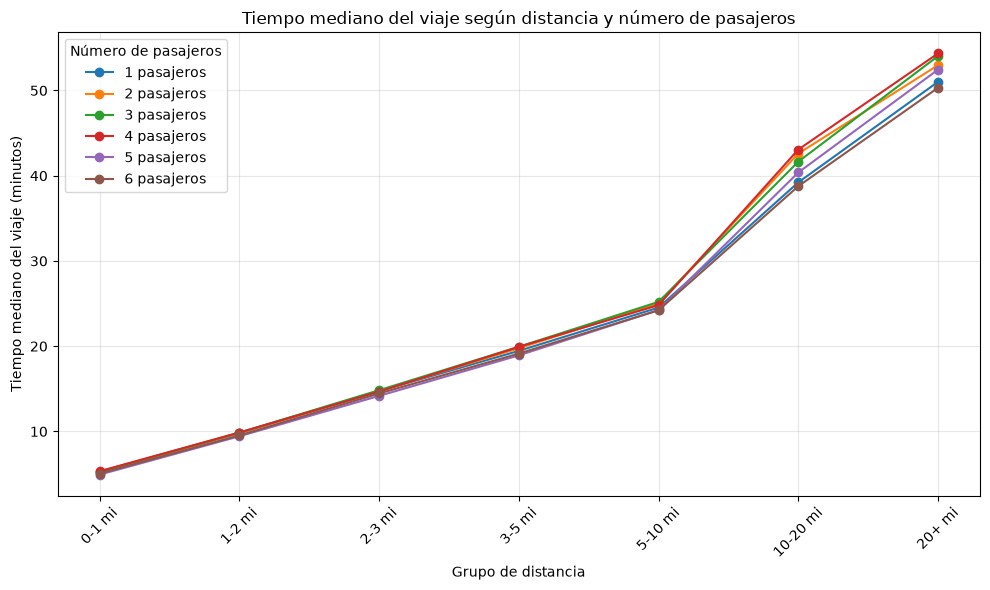

In [49]:
import matplotlib.pyplot as plt

# Convertir la tabla agrupada en un formato para graficar
tabla_reset = tabla.reset_index()

# Si hay muchos valores raros en passenger_count, puedes limitarlo
tabla_reset = tabla_reset[tabla_reset["passenger_count"].between(1, 6)]

# Crear tabla pivote:
# filas = distance_group
# columnas = passenger_count
# valores = tiempo_mediano
tabla_plot = tabla_reset.pivot(
    index="distance_group",
    columns="passenger_count",
    values="tiempo_mediano"
)

# Graficar
plt.figure(figsize=(10, 6))

for pasajeros in tabla_plot.columns:
    plt.plot(
        tabla_plot.index.astype(str),
        tabla_plot[pasajeros],
        marker="o",
        label=f"{int(pasajeros)} pasajeros"
    )

plt.title("Tiempo mediano del viaje según distancia y número de pasajeros")
plt.xlabel("Grupo de distancia")
plt.ylabel("Tiempo mediano del viaje (minutos)")
plt.xticks(rotation=45)
plt.legend(title="Número de pasajeros")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

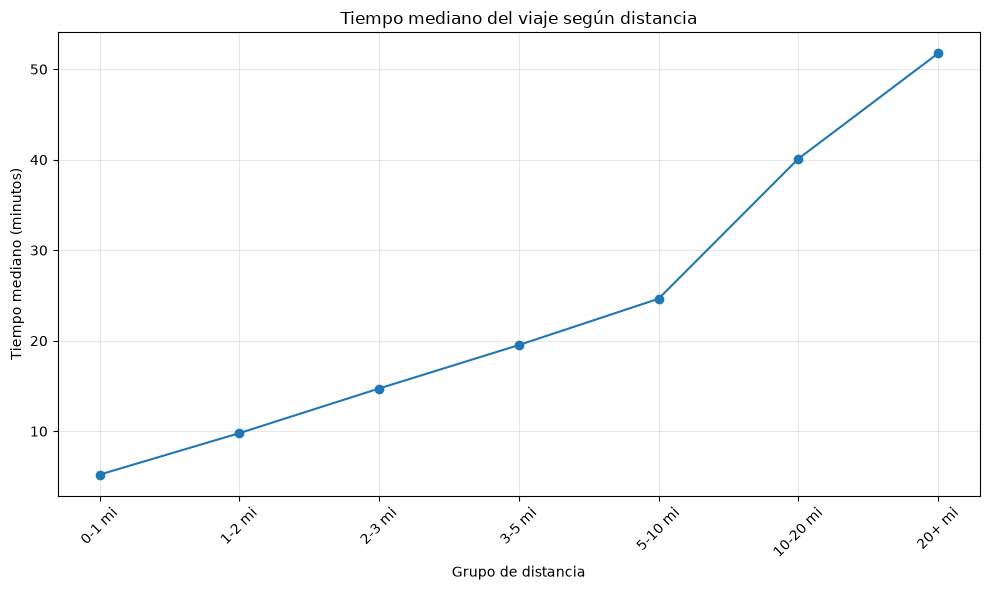

In [50]:
distancia_tiempo = (
    df_clean
    .groupby("distance_group", observed=True)
    .agg(
        tiempo_mediano=("trip_duration_min", "median"),
        tiempo_promedio=("trip_duration_min", "mean")
    )
)

distancia_tiempo.plot(
    y="tiempo_mediano",
    marker="o",
    figsize=(10, 6),
    legend=False
)

plt.title("Tiempo mediano del viaje según distancia")
plt.xlabel("Grupo de distancia")
plt.ylabel("Tiempo mediano (minutos)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
df_clean["passenger_count"].value_counts().sort_index()

passenger_count
1.0    2513339
2.0     532285
3.0     134862
4.0      55010
5.0      60302
6.0      41553
7.0          6
8.0          6
Name: count, dtype: int64

In [52]:
df_clean.groupby(
    ["distance_group", "passenger_count"],
    observed=True
).size().unstack()

passenger_count,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
distance_group,,,,,,,,
0-1 mi,507626.0,98033.0,24663.0,9623.0,11080.0,7737.0,2.0,NaN
1-2 mi,817081.0,163333.0,42954.0,17243.0,19259.0,13532.0,NaN,NaN
2-3 mi,430248.0,88373.0,23091.0,9369.0,10621.0,7102.0,NaN,1.0
3-5 mi,320459.0,68639.0,18144.0,7677.0,8181.0,5637.0,1.0,NaN
5-10 mi,230097.0,48568.0,12452.0,5327.0,5773.0,3837.0,3.0,1.0
10-20 mi,181786.0,56716.0,11846.0,5084.0,4758.0,3255.0,NaN,3.0
20+ mi,26042.0,8623.0,1712.0,687.0,630.0,453.0,NaN,1.0


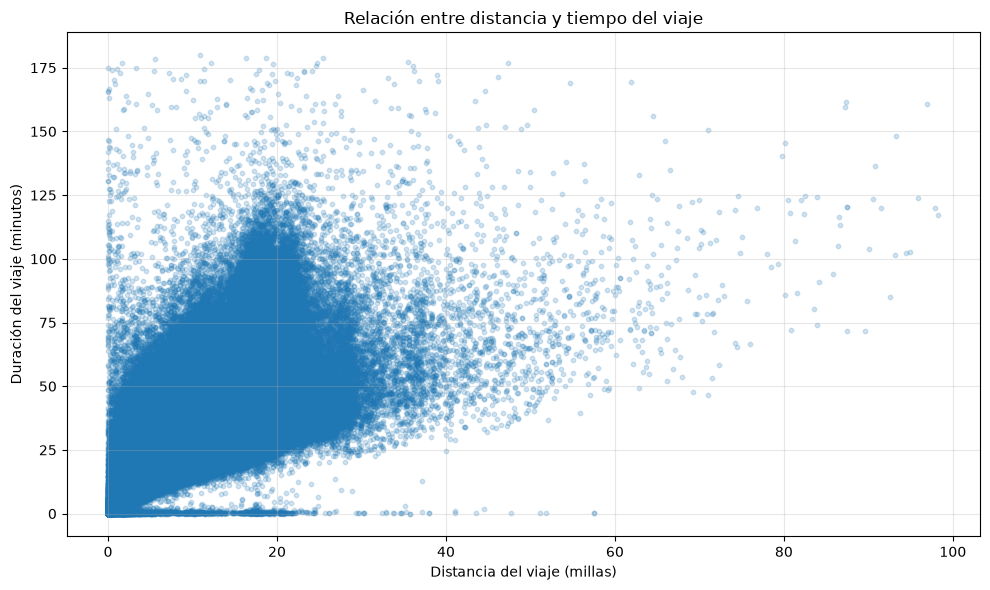

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["trip_distance"],
    df_clean["trip_duration_min"],
    alpha=0.2,
    s=10
)

plt.title("Relación entre distancia y tiempo del viaje")
plt.xlabel("Distancia del viaje (millas)")
plt.ylabel("Duración del viaje (minutos)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

df_mayo = pd.read_parquet("yellow_tripdata_2022-05.parquet")
df_julio = pd.read_parquet("yellow_tripdata_2022-07.parquet")

In [55]:
df_mayo["trip_duration_min"] = (
    df_mayo["tpep_dropoff_datetime"] - df_mayo["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df_julio["trip_duration_min"] = (
    df_julio["tpep_dropoff_datetime"] - df_julio["tpep_pickup_datetime"]
).dt.total_seconds() / 60

In [56]:
df_mayo_clean = df_mayo[
    (df_mayo["trip_duration_min"] > 0) &
    (df_mayo["trip_duration_min"] <= 180) &
    (df_mayo["trip_distance"] > 0) &
    (df_mayo["trip_distance"] <= 100)
].copy()

df_julio_clean = df_julio[
    (df_julio["trip_duration_min"] > 0) &
    (df_julio["trip_duration_min"] <= 180) &
    (df_julio["trip_distance"] > 0) &
    (df_julio["trip_distance"] <= 100)
].copy()

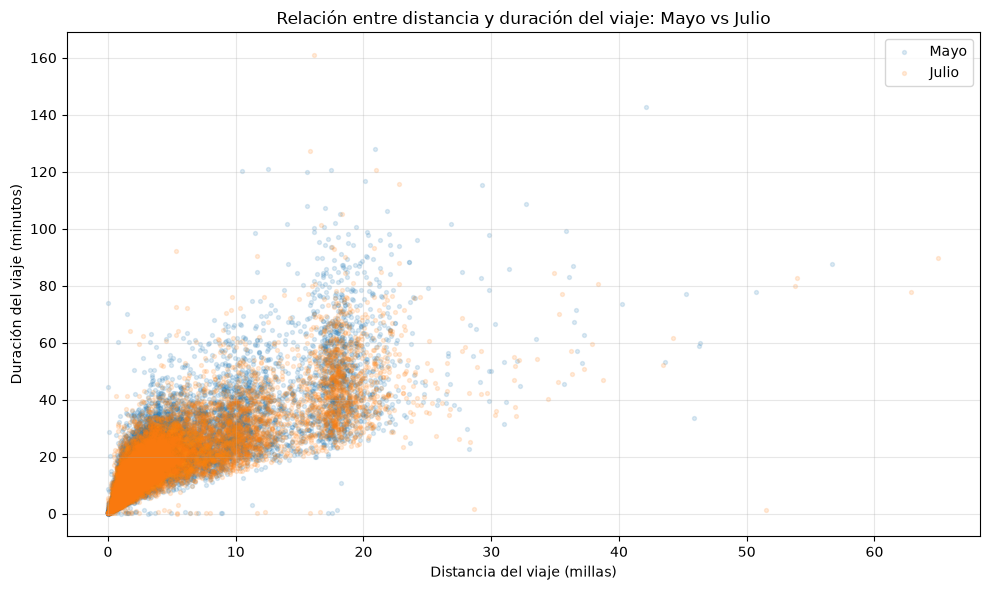

In [57]:
muestra_mayo = df_mayo_clean.sample(
    n=min(20000, len(df_mayo_clean)),
    random_state=42
)

muestra_julio = df_julio_clean.sample(
    n=min(20000, len(df_julio_clean)),
    random_state=42
)

plt.figure(figsize=(10, 6))

plt.scatter(
    muestra_mayo["trip_distance"],
    muestra_mayo["trip_duration_min"],
    alpha=0.15,
    s=8,
    label="Mayo"
)

plt.scatter(
    muestra_julio["trip_distance"],
    muestra_julio["trip_duration_min"],
    alpha=0.15,
    s=8,
    label="Julio"
)

plt.title("Relación entre distancia y duración del viaje: Mayo vs Julio")
plt.xlabel("Distancia del viaje (millas)")
plt.ylabel("Duración del viaje (minutos)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
distance_bins = [0, 1, 2, 3, 5, 10, 20, 100]

distance_labels = [
    "0-1 mi",
    "1-2 mi",
    "2-3 mi",
    "3-5 mi",
    "5-10 mi",
    "10-20 mi",
    "20+ mi"
]

df_mayo_clean["distance_group"] = pd.cut(
    df_mayo_clean["trip_distance"],
    bins=distance_bins,
    labels=distance_labels
)

df_julio_clean["distance_group"] = pd.cut(
    df_julio_clean["trip_distance"],
    bins=distance_bins,
    labels=distance_labels
)

In [59]:
mayo_resumen = (
    df_mayo_clean
    .groupby("distance_group", observed=True)
    .agg(
        tiempo_mediano=("trip_duration_min", "median")
    )
)

julio_resumen = (
    df_julio_clean
    .groupby("distance_group", observed=True)
    .agg(
        tiempo_mediano=("trip_duration_min", "median")
    )
)

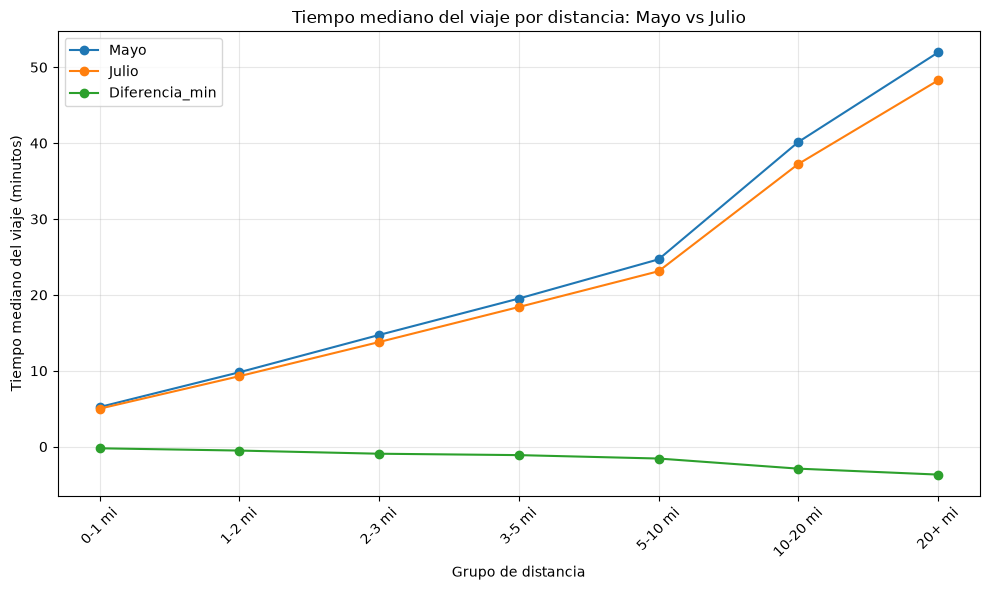

In [60]:
comparacion.plot(
    marker="o",
    figsize=(10, 6)
)

plt.title("Tiempo mediano del viaje por distancia: Mayo vs Julio")
plt.xlabel("Grupo de distancia")
plt.ylabel("Tiempo mediano del viaje (minutos)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
comparacion["Diferencia_min"] = comparacion["Julio"] - comparacion["Mayo"]

comparacion

,Mayo,Julio,Diferencia_min
distance_group,,,
0-1 mi,5.216667,5.000000,-0.216667
1-2 mi,9.800000,9.283333,-0.516667
2-3 mi,14.716667,13.783333,-0.933333
3-5 mi,19.516667,18.400000,-1.116667
5-10 mi,24.683333,23.116667,-1.566667
10-20 mi,40.150000,37.250000,-2.900000
20+ mi,51.950000,48.266667,-3.683333


In [62]:
df_julio.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_min
0,1,2022-07-01 00:20:06,2022-07-01 00:39:13,1.0,10.10,1.0,N,70,33,1,28.5,0.5,0.5,8.9,0.0,0.3,38.7,0.0,0.0,19.116667
1,2,2022-07-01 00:29:11,2022-07-01 00:38:00,1.0,1.67,1.0,N,162,48,1,8.0,0.5,0.5,1.0,0.0,0.3,12.8,2.5,0.0,8.816667
2,1,2022-07-01 00:03:56,2022-07-01 00:11:49,1.0,0.90,1.0,N,48,142,1,6.0,3.0,0.5,2.0,0.0,0.3,11.8,2.5,0.0,7.883333
3,1,2022-07-01 00:18:36,2022-07-01 00:52:44,1.0,14.80,1.0,N,70,265,1,44.0,0.5,0.5,20.0,0.0,0.3,65.3,0.0,0.0,34.133333
4,1,2022-07-01 00:15:50,2022-07-01 00:22:21,1.0,1.20,1.0,N,161,234,2,6.5,3.0,0.5,0.0,0.0,0.3,10.3,2.5,0.0,6.516667


In [63]:
df_julio.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          105194
trip_distance                 0
RatecodeID               105194
store_and_fwd_flag       105194
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     105194
airport_fee              105194
trip_duration_min             0
dtype: int64

# ¿El precio aumenta con el número de pasajeros? 

Se compararon grupos de 1 a 6 pasajeron dentro de dos franjas estrechas de distancia: 10 a menos de 10.5 millas y 15 a menos de 15.5 millas. **Son distancias similares, no idénticas**. 





# 1. Peparar rutas e importa bibliotecas

In [ ]:
from pathlib import Path
from decimal import Decimal, ROUND_HALF_UP
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

ARCHIVO = Path("yellow_tripdata_2022-05.parquet")
if not ARCHIVO.exists():
    ARCHIVO = Path("upload") / ARCHIVO.name

# Intervalos en millas para analizar los viajes.
INTERVALOS = [(10, 10.5), (15, 15.5)]
PASAJEROS = list(range(1, 7))
SALIDA = Path("resultados")
SALIDA.mkdir(exist_ok=True)

def dinero(valor):
    return format(Decimal(str(valor)).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP), ".2f")


# 2. Leer archivo y aplicar filtros básicos


In [65]:
columnas = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance",
    "passenger_count", "RatecodeID", "payment_type", "fare_amount", "total_amount"
]
df = pd.read_parquet(ARCHIVO, columns=columnas)
df["duracion_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Filtros básicos, aplicados igual a todos los grupos. El original no se modifica.
# El rango de duración es un criterio exploratorio: no declara inválido todo
# viaje que dure más de 180 minutos. Se excluyen aquí para facilitar la comparación.
filtro = (
    df["tpep_pickup_datetime"].ge("2022-05-01")
    & df["tpep_pickup_datetime"].lt("2022-06-01")
    & df["passenger_count"].isin(PASAJEROS)
    & df["RatecodeID"].eq(1)
    & df["payment_type"].eq(1)
    & df["trip_distance"].gt(0)
    & df["fare_amount"].gt(0)
    & df["total_amount"].gt(0)
    & df["duracion_min"].between(1, 180)
)
df_comparar = df.loc[filtro].copy()
df_comparar["passenger_count"] = df_comparar["passenger_count"].astype(int)
print(f"Registros originales: {len(df):,}")
print(f"Registros después de filtros básicos: {len(df_comparar):,}")
columnas = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance",
    "passenger_count", "RatecodeID", "payment_type", "fare_amount", "total_amount"
]
df = pd.read_parquet(ARCHIVO, columns=columnas)
df["duracion_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Filtros básicos, aplicados igual a todos los grupos. El original no se modifica.
# El rango de duración es un criterio exploratorio: no declara inválido todo
# viaje que dure más de 180 minutos. Se excluyen aquí para facilitar la comparación.
filtro = (
    df["tpep_pickup_datetime"].ge("2022-05-01")
    & df["tpep_pickup_datetime"].lt("2022-06-01")
    & df["passenger_count"].isin(PASAJEROS)
    & df["RatecodeID"].eq(1)
    & df["payment_type"].eq(1)
    & df["trip_distance"].gt(0)
    & df["fare_amount"].gt(0)
    & df["total_amount"].gt(0)
    & df["duracion_min"].between(1, 180)
)
df_comparar = df.loc[filtro].copy()
df_comparar["passenger_count"] = df_comparar["passenger_count"].astype(int)
print(f"Registros originales: {len(df):,}")
print(f"Registros después de filtros básicos: {len(df_comparar):,}")


Registros originales: 3,588,295
Registros después de filtros básicos: 2,490,197
Registros originales: 3,588,295
Registros después de filtros básicos: 2,490,197


# 3. Resumir por franja de distancia y pasajeros

Se conserva la precisión completa para los cálculos. La mediana es el valor central del grupo, no el promedio.


In [66]:
grupos = {}
tablas = []
for inferior, superior in INTERVALOS:
    etiqueta = f"{inferior:g} a <{superior:g} millas"
    datos = df_comparar.loc[
        df_comparar["trip_distance"].ge(inferior)
        & df_comparar["trip_distance"].lt(superior)
    ].copy()
    grupos[etiqueta] = datos
    tabla = datos.groupby("passenger_count").agg(
        numero_viajes=("total_amount", "size"),
        total_mediano=("total_amount", "median"),
        total_promedio=("total_amount", "mean"),
        total_q25=("total_amount", lambda x: x.quantile(0.25)),
        total_q75=("total_amount", lambda x: x.quantile(0.75)),
        tarifa_mediana=("fare_amount", "median"),
        distancia_mediana=("trip_distance", "median"),
        duracion_mediana=("duracion_min", "median"),
    ).reset_index()
    tabla.insert(0, "intervalo", etiqueta)
    tablas.append(tabla)

resumen = pd.concat(tablas, ignore_index=True)
print(resumen.round(3).to_string(index=False))
print(f"\nViajes representados en la gráfica: {resumen['numero_viajes'].sum():,}")


        intervalo  passenger_count  numero_viajes  total_mediano  total_promedio  total_q25  total_q75  tarifa_mediana  distancia_mediana  duracion_mediana
10 a <10.5 millas                1          13919         49.020          48.669     43.560     52.940            32.0              10.22            31.000
10 a <10.5 millas                2           3015         49.600          49.178     44.300     53.250            32.5              10.22            31.767
10 a <10.5 millas                3            652         49.580          49.079     44.448     53.270            32.5              10.21            31.633
10 a <10.5 millas                4            276         49.145          49.192     44.160     53.520            32.0              10.24            31.417
10 a <10.5 millas                5            315         49.120          48.869     44.160     52.620            32.0              10.26            31.150
10 a <10.5 millas                6            227         48.810

# 4.Graficar

La fila superior muestra el total registrado; la inferior , la tarifa del táximetro. Las columnas corresponden a diferentes franjas de distancia. 

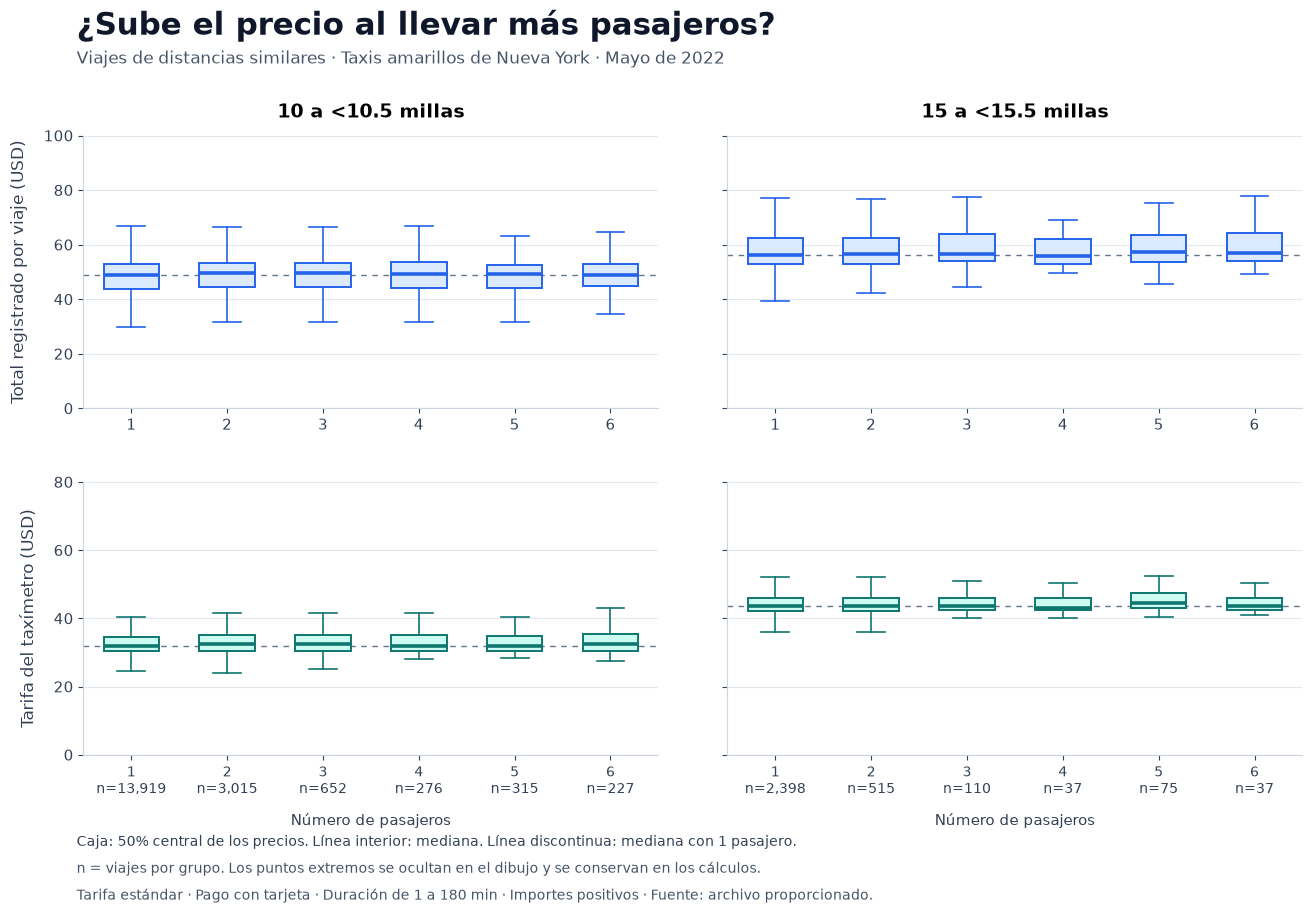

In [67]:
# Cada caja contiene el 50% central de los precios; la línea interior es la mediana.
# Los bigotes siguen la regla habitual de 1.5 veces el rango intercuartílico.
# showfliers=False oculta los puntos extremos, pero no los elimina de los cálculos.
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#CBD5E1", "axes.labelcolor": "#334155",
    "xtick.color": "#334155", "ytick.color": "#334155",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
fig, axes = plt.subplots(2, len(grupos), figsize=(13.5, 9.6),
                         sharey="row", squeeze=False)
metricas = [
    ("total_amount", "Total registrado por viaje (USD)", "#2563EB", "#DBEAFE"),
    ("fare_amount", "Tarifa del taxímetro (USD)", "#0F766E", "#CCFBF1"),
]

for columna, (etiqueta, datos) in enumerate(grupos.items()):
    conteos = datos["passenger_count"].value_counts()
    for fila, (variable, titulo_y, color, relleno) in enumerate(metricas):
        ax = axes[fila, columna]
        series = [datos.loc[datos["passenger_count"].eq(p), variable].to_numpy()
                  for p in PASAJEROS]
        ax.boxplot(series, positions=PASAJEROS, widths=0.58,
                   patch_artist=True, showfliers=False,
                   boxprops={"facecolor": relleno, "edgecolor": color, "linewidth": 1.4},
                   medianprops={"color": color, "linewidth": 2.6},
                   whiskerprops={"color": color, "linewidth": 1.2},
                   capprops={"color": color, "linewidth": 1.2})
        referencia = datos.loc[datos["passenger_count"].eq(1), variable].median()
        ax.axhline(referencia, color="#64748B", linestyle=(0, (4, 4)),
                   linewidth=1, zorder=0)
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="#E2E8F0", linewidth=0.8)
        ax.yaxis.set_major_locator(MultipleLocator(20))
        # Mismo origen y escala dentro de cada fila; los bigotes quedan visibles.
        ax.set_ylim(0, 100 if fila == 0 else 80)
        ax.set_xticks(PASAJEROS)
        if fila == 0:
            ax.set_title(etiqueta, fontsize=14, weight="bold", pad=13)
        else:
            ax.set_xticklabels([f"{p}\nn={conteos.get(p, 0):,}" for p in PASAJEROS], fontsize=10)
            ax.set_xlabel("Número de pasajeros", labelpad=11)
        if columna == 0:
            ax.set_ylabel(titulo_y, fontsize=12, labelpad=12)

fig.suptitle("¿Sube el precio al llevar más pasajeros?", x=0.07, y=0.976,
             ha="left", fontsize=22, weight="bold", color="#0F172A")
fig.text(0.07, 0.920, "Viajes de distancias similares · Taxis amarillos de Nueva York · Mayo de 2022",
         fontsize=12, color="#475569")
fig.subplots_adjust(left=0.075, right=0.978, top=0.845, bottom=0.20, hspace=0.27, wspace=0.12)
fig.text(0.07, 0.105,
         "Caja: 50% central de los precios. Línea interior: mediana. Línea discontinua: mediana con 1 pasajero.",
         fontsize=10, color="#334155")
fig.text(0.07, 0.077,
         "n = viajes por grupo. Los puntos extremos se ocultan en el dibujo y se conservan en los cálculos.",
         fontsize=10, color="#475569")
fig.text(0.07, 0.049,
         "Tarifa estándar · Pago con tarjeta · Duración de 1 a 180 min · Importes positivos · Fuente: archivo proporcionado.",
         fontsize=10, color="#475569")
RUTA_GRAFICA = SALIDA / "precio_por_pasajeros_mayo_2022.png"
fig.savefig(RUTA_GRAFICA, dpi=160, facecolor="white")
plt.show()


# ¿Cómo interpretar la gráfica? 

- Compara las cajas **dentro de cada panel**. Si las medianas subieran de forma consistente al aumentar los pasajeros, habría una asociación descriptiva. 
- La tarifa del taxímetro y el total se presentan por separado para distinguir lo registrado en el taxímetro de los demás componentes del pago. 
- Un solapamiento de cajas no es una prueba estadística de igualdad. No se estima un efecto causal ni se realiza aquí una prueba de significancia. 
- Controlar la distancia mediante intervales no la iguala exactamente. Tampoco iguala duración, horario, origen/destino, pejaes, propinas o proveedor de registros. 
- n muestra el numero de grupos. Los grupos pequeños, especialemnte los de 4 y 6 pasajeros en 15-15.5 millas, requieren más cautela. 
- Los extremos positivos no se recortan por precio. La mediana reduce su influencia; los puntos extremos solamente se ocultan para facilitar la lectura de las cajas. 
- Para evaluar una asociación ajustada, el siguiente paso sería comparar viajes semejantes también en duración, horario, zonas y carhas, o ajustar un modelo de regresión. Esto tampoco demostraría por sí solo una causa.


# Comparación con distancias exactamente igual. 

In [68]:
misma_distancia = df_comparar.loc[df_comparar["trip_distance"].eq(10.0)]
print(misma_distancia.groupby("passenger_count")["total_amount"].agg(["size", "median"]))

                 size  median
passenger_count              
1                 967  47.960
2                 237  48.720
3                  40  44.670
4                  22  48.750
5                   6  45.505
6                   6  46.830


# Resultados.
En estas dos franjas no se observa un aumento consistente de las medianas al
pasar de 1 a 6 pasajeros. En 10–10.5 millas el total mediano pasa de USD 49.02
a USD 48.81; en 15–15.5 millas, de USD 56.21 a USD 57.06. En la segunda franja
la tarifa mediana del taxímetro es USD 43.50 para ambos grupos.
Estos valores describen la selección analizada; no prueban que el número de
pasajeros cause o no cause diferencias. En 15–15.5 millas solo hay 37 viajes con
6 pasajeros, frente a 2,398 con 1 pasajero. La conclusión es exploratoria.
